# Étape 4 (variante) — Semi-supervisé avec optimisation des hyperparamètres

**Projet BrainScanAI** - Détection de tumeurs cérébrales

Ce notebook est identique à `semi_supervised_learning.ipynb` mais ajoute une **recherche d'hyperparamètres** par validation croisée stratifiée (StratifiedKFold, k=5) sur les 80 images train fortement labelisées.

Les meilleurs hyperparamètres sont ensuite utilisés pour entraîner les modèles A, B et C.

## 1. Imports

In [1]:
import sys
from pathlib import Path
from itertools import product

sys.path.append(str(Path("..").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    fbeta_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
)

print("Imports OK")
print(f"PyTorch version : {torch.__version__}")

Imports OK
PyTorch version : 2.2.2+cpu


## 2. Configuration

In [2]:
from src.config import PROCESSED_DIR, FEATURES_DIR, RESULTS_DIR, RANDOM_STATE, DEVICE

INPUT_DIM     = 2048
N_CLASSES     = 2
EPOCHS_WEAK   = 30   # Phase 1 : pré-entraînement sur labels faibles
EPOCHS_STRONG = 30   # Phase 2 : fine-tuning sur labels forts
BATCH_SMALL   = 16
BATCH_LARGE   = 64

torch.manual_seed(RANDOM_STATE)
print(f"Appareil : {DEVICE}  |  Graine : {RANDOM_STATE}")

Appareil : cpu  |  Graine : 42


## 3. Chargement des données

In [3]:
features_raw     = np.load(FEATURES_DIR / "resnet50_features.npy")
meta             = pd.read_csv(PROCESSED_DIR / "metadata_weak_labels_dbscan.csv")
test_meta        = pd.read_csv(PROCESSED_DIR / "test_set.csv")
features_aug_raw = np.load(FEATURES_DIR / "resnet50_features_augmented.npy")
meta_aug         = pd.read_csv(FEATURES_DIR / "resnet50_metadata_augmented.csv")

print(f"Features originales : {features_raw.shape}")
print(f"Features augmentées : {features_aug_raw.shape}")
print(f"Test set            : {test_meta.shape}")

Features originales : (1506, 2048)
Features augmentées : (720, 2048)
Test set            : (20, 3)


In [4]:
test_paths = set(test_meta["path"].values)
is_test    = meta["path"].isin(test_paths).values

features_train_all = features_raw[~is_test]
features_test      = features_raw[is_test]
meta_train         = meta[~is_test].reset_index(drop=True)
meta_test          = meta[is_test].reset_index(drop=True)

labels_test = (meta_test["label"] == "cancer").astype(int).values

is_strong       = meta_train["label"].notna().values
features_strong = features_train_all[is_strong]
labels_strong   = (meta_train[is_strong]["label"] == "cancer").astype(int).values

labels_all_train_dbscan = np.where(
    meta_train["label"].notna(),
    (meta_train["label"] == "cancer").astype(int),
    (meta_train["weak_label_dbscan"] == "cancer").astype(int)
)

features_aug_train = features_aug_raw
labels_aug_train   = (meta_aug["label"] == "cancer").astype(int).values

print(f"Train : {features_train_all.shape[0]}  |  Fortement labelisées : {is_strong.sum()}")
print(f"Augmentées : {features_aug_train.shape[0]}  |  Test : {features_test.shape[0]}")

Train : 1486  |  Fortement labelisées : 80
Augmentées : 720  |  Test : 20


## 4. Standardisation

StandardScaler entraîné sur les 1486 images non-test uniquement — éviter le data leakage.

In [5]:
scaler = StandardScaler()
scaler.fit(features_train_all)

features_train_scaled     = scaler.transform(features_train_all)
features_strong_scaled    = scaler.transform(features_strong)
features_aug_train_scaled = scaler.transform(features_aug_train)
features_test_scaled      = scaler.transform(features_test)

print(f"Standardisation OK — moyenne : {features_train_scaled.mean():.4f}, std : {features_train_scaled.std():.4f}")

Standardisation OK — moyenne : 0.0000, std : 1.0000


## 5. Dataset PyTorch

In [6]:
class FeaturesDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.FloatTensor(features)
        self.labels   = torch.LongTensor(labels)
    def __len__(self):          return len(self.features)
    def __getitem__(self, idx): return self.features[idx], self.labels[idx]


dataset_strong     = FeaturesDataset(features_strong_scaled, labels_strong)
dataset_all_dbscan = FeaturesDataset(features_train_scaled,  labels_all_train_dbscan)

features_all_aug = np.vstack([features_train_scaled, features_aug_train_scaled])
labels_all_aug   = np.concatenate([labels_all_train_dbscan, labels_aug_train])
dataset_all_aug  = FeaturesDataset(features_all_aug, labels_all_aug)

dataset_test = FeaturesDataset(features_test_scaled, labels_test)

loader_all_dbscan = DataLoader(dataset_all_dbscan, batch_size=BATCH_LARGE, shuffle=True)
loader_all_aug    = DataLoader(dataset_all_aug,    batch_size=BATCH_LARGE, shuffle=True)
loader_test       = DataLoader(dataset_test,       batch_size=BATCH_SMALL, shuffle=False)

print(f"A : {len(dataset_strong)} | B : {len(dataset_all_dbscan)} | C : {len(dataset_all_aug)} | Test : {len(dataset_test)}")

A : 80 | B : 1486 | C : 2206 | Test : 20


## 6. Architecture MLP

- **BatchNorm** : normalise les activations pour stabiliser l'entraînement
- **Dropout** : désactive aléatoirement des neurones pendant l'entraînement pour éviter le sur-apprentissage
- **ReLU** : fonction d'activation non-linéaire

In [7]:
class MLPClassifier(nn.Module):
    """Classifieur MLP sur les features ResNet50."""
    def __init__(self, input_dim=2048, hidden_dim=512, n_classes=2, dropout=0.4):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout * 0.75),
            nn.Linear(128, n_classes),
        )
    def forward(self, x): return self.network(x)

n_params = sum(p.numel() for p in MLPClassifier().parameters())
print(f"Paramètres (config par défaut) : {n_params:,}")

Paramètres (config par défaut) : 1,116,290


## 7. Fonctions d'entraînement et d'évaluation

In [8]:
def train_model(model, loader, optimizer, criterion, device, n_epochs, desc="", verbose=True):
    model.train()
    losses = []
    for epoch in range(n_epochs):
        epoch_loss = 0.0
        for features, labels in loader:
            features, labels = features.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(features), labels)
            loss.backward(); optimizer.step()
            epoch_loss += loss.item()
        avg_loss = epoch_loss / len(loader)
        losses.append(avg_loss)
        if verbose and (epoch + 1) % 10 == 0:
            print(f"  {desc} Epoch {epoch+1:3d}/{n_epochs} — Loss : {avg_loss:.4f}")
    return losses


def evaluate_model(model, loader, device):
    model.eval()
    all_preds, all_labels, all_probas = [], [], []
    with torch.no_grad():
        for features, labels in loader:
            outputs = model(features.to(device))
            all_probas.extend(torch.softmax(outputs, dim=1)[:, 1].cpu().numpy())
            all_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds), np.array(all_probas)


def print_metrics(y_true, y_pred, y_proba, model_name):
    acc = accuracy_score(y_true, y_pred)
    f2  = fbeta_score(y_true, y_pred, beta=2, average="macro")
    auc = roc_auc_score(y_true, y_proba)
    print(f"\n{'='*50}")
    print(f"Modèle : {model_name}")
    print(f"  Accuracy : {acc:.4f}  |  F2-score : {f2:.4f}  |  ROC-AUC : {auc:.4f}")
    print(f"{'='*50}")
    print(classification_report(y_true, y_pred, target_names=["normal", "cancer"]))
    return acc, f2, auc

criterion = nn.CrossEntropyLoss()
print("Fonctions définies.")

Fonctions définies.


## 8. Recherche d'hyperparamètres — StratifiedKFold (k=5)

### Pourquoi la validation croisée stratifiée ?

Avec seulement **80 images train**, on ne peut pas mettre de côté un jeu de validation fixe sans appauvrir davantage l'entraînement. La validation croisée à k=5 utilise toutes les images pour l'évaluation, tout en gardant le test set (20 images) complètement hors de la boucle.

Avec `StratifiedKFold`, chaque fold respecte la proportion cancer/normal :
- Fold de validation : ~16 images (8 cancer + 8 normal)
- Fold d'entraînement : ~64 images

### Métrique optimisée : F2-score (β=2)

Cohérent avec le contexte médical — rappel deux fois plus important que la précision pour réduire les faux négatifs.

In [9]:
param_grid = {
    "lr":         [1e-3, 5e-4],
    "dropout":    [0.3, 0.4],
    "hidden_dim": [512, 256],
    "epochs":     [50, 100],
}

n_combos = 1
for v in param_grid.values(): n_combos *= len(v)
print(f"Grille : {n_combos} combinaisons × 5 folds = {n_combos * 5} entraînements")
print(f"Hyperparamètres : {param_grid}")

Grille : 16 combinaisons × 5 folds = 80 entraînements
Hyperparamètres : {'lr': [0.001, 0.0005], 'dropout': [0.3, 0.4], 'hidden_dim': [512, 256], 'epochs': [50, 100]}


In [10]:
skf        = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
keys       = list(param_grid.keys())
values     = list(param_grid.values())
results_hp = []

print("Recherche en cours...\n")
for combo in product(*values):
    params   = dict(zip(keys, combo))
    fold_f2  = []

    for train_idx, val_idx in skf.split(features_strong_scaled, labels_strong):
        X_tr, X_val = features_strong_scaled[train_idx], features_strong_scaled[val_idx]
        y_tr, y_val = labels_strong[train_idx],          labels_strong[val_idx]

        ld_tr  = DataLoader(FeaturesDataset(X_tr, y_tr),   batch_size=BATCH_SMALL, shuffle=True)
        ld_val = DataLoader(FeaturesDataset(X_val, y_val), batch_size=BATCH_SMALL, shuffle=False)

        model_cv = MLPClassifier(INPUT_DIM, params["hidden_dim"], N_CLASSES, params["dropout"]).to(DEVICE)
        opt_cv   = torch.optim.Adam(model_cv.parameters(), lr=params["lr"])
        train_model(model_cv, ld_tr, opt_cv, criterion, DEVICE, params["epochs"], verbose=False)

        y_t, y_p, _ = evaluate_model(model_cv, ld_val, DEVICE)
        fold_f2.append(fbeta_score(y_t, y_p, beta=2, average="macro", zero_division=0))

    mean_f2 = np.mean(fold_f2)
    std_f2  = np.std(fold_f2)
    results_hp.append({**params, "mean_f2": mean_f2, "std_f2": std_f2})
    print(f"lr={params['lr']:.0e} | dropout={params['dropout']} | hidden={params['hidden_dim']:3d} | "
          f"epochs={params['epochs']:3d} → F2 = {mean_f2:.4f} ± {std_f2:.4f}")

Recherche en cours...

lr=1e-03 | dropout=0.3 | hidden=512 | epochs= 50 → F2 = 0.9369 ± 0.0395
lr=1e-03 | dropout=0.3 | hidden=512 | epochs=100 → F2 = 0.9238 ± 0.0476
lr=1e-03 | dropout=0.3 | hidden=256 | epochs= 50 → F2 = 0.9492 ± 0.0254
lr=1e-03 | dropout=0.3 | hidden=256 | epochs=100 → F2 = 0.9361 ± 0.0408
lr=1e-03 | dropout=0.4 | hidden=512 | epochs= 50 → F2 = 0.9361 ± 0.0408
lr=1e-03 | dropout=0.4 | hidden=512 | epochs=100 → F2 = 0.9238 ± 0.0476
lr=1e-03 | dropout=0.4 | hidden=256 | epochs= 50 → F2 = 0.9107 ± 0.0511
lr=1e-03 | dropout=0.4 | hidden=256 | epochs=100 → F2 = 0.9242 ± 0.0246
lr=5e-04 | dropout=0.3 | hidden=512 | epochs= 50 → F2 = 0.9492 ± 0.0254
lr=5e-04 | dropout=0.3 | hidden=512 | epochs=100 → F2 = 0.9369 ± 0.0395
lr=5e-04 | dropout=0.3 | hidden=256 | epochs= 50 → F2 = 0.9369 ± 0.0395
lr=5e-04 | dropout=0.3 | hidden=256 | epochs=100 → F2 = 0.9238 ± 0.0476
lr=5e-04 | dropout=0.4 | hidden=512 | epochs= 50 → F2 = 0.9369 ± 0.0395
lr=5e-04 | dropout=0.4 | hidden=512 | epo

## 9. Résultats de la recherche

In [11]:
df_hp = pd.DataFrame(results_hp).sort_values("mean_f2", ascending=False).reset_index(drop=True)

print("Top 5 combinaisons (triées par F2-score moyen) :")
print(df_hp.head().to_string(index=False))

best         = df_hp.iloc[0]
BEST_LR      = best["lr"]
BEST_DROPOUT = best["dropout"]
BEST_HIDDEN  = int(best["hidden_dim"])
BEST_EPOCHS  = int(best["epochs"])

print(f"\n{'='*50}")
print(f"Meilleurs hyperparamètres :")
print(f"  Learning rate  : {BEST_LR}")
print(f"  Dropout        : {BEST_DROPOUT}")
print(f"  Hidden dim     : {BEST_HIDDEN}")
print(f"  Epochs         : {BEST_EPOCHS}")
print(f"  F2 CV moyen    : {best['mean_f2']:.4f} ± {best['std_f2']:.4f}")
print(f"{'='*50}")

Top 5 combinaisons (triées par F2-score moyen) :
    lr  dropout  hidden_dim  epochs  mean_f2   std_f2
0.0010      0.3         256      50 0.949218 0.025391
0.0005      0.3         512      50 0.949218 0.025391
0.0005      0.4         256     100 0.949218 0.025391
0.0010      0.3         512      50 0.936914 0.039531
0.0005      0.3         512     100 0.936914 0.039531

Meilleurs hyperparamètres :
  Learning rate  : 0.001
  Dropout        : 0.3
  Hidden dim     : 256
  Epochs         : 50
  F2 CV moyen    : 0.9492 ± 0.0254


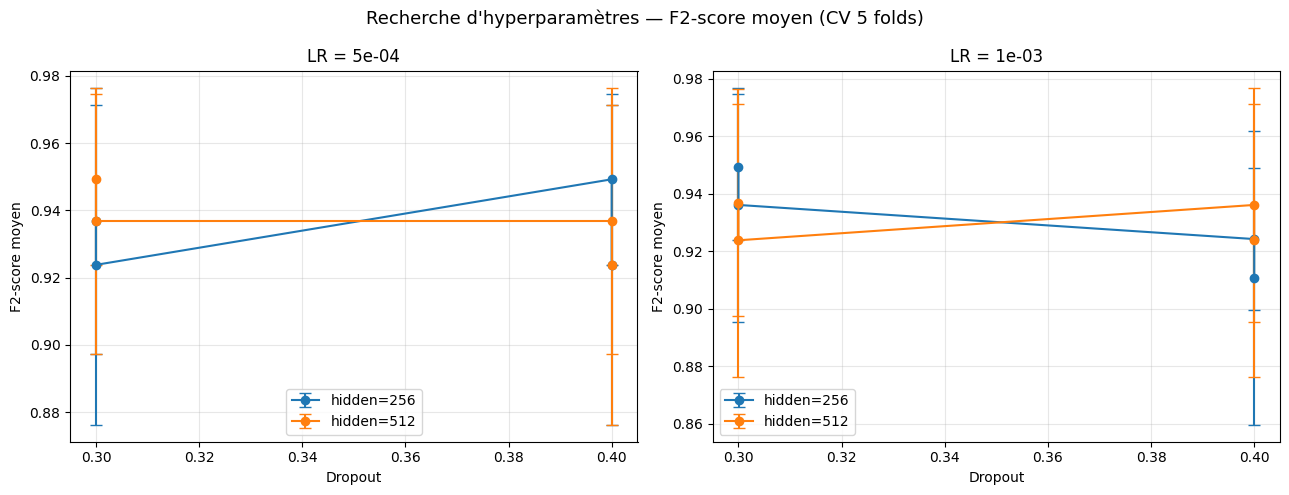

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Recherche d'hyperparamètres — F2-score moyen (CV 5 folds)", fontsize=13)

for ax, lr_val in zip(axes, sorted(df_hp["lr"].unique())):
    subset = df_hp[df_hp["lr"] == lr_val]
    for hidden in sorted(subset["hidden_dim"].unique()):
        sub2 = subset[subset["hidden_dim"] == hidden].sort_values("dropout")
        ax.errorbar(sub2["dropout"], sub2["mean_f2"], yerr=sub2["std_f2"],
                    marker="o", label=f"hidden={hidden}", capsize=4)
    ax.set_title(f"LR = {lr_val:.0e}")
    ax.set_xlabel("Dropout"); ax.set_ylabel("F2-score moyen")
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "hp_search_results.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Modèle A — Supervisé pur (HP optimisés)

Entraînement sur les **80 images fortement labelisées** avec les meilleurs HP trouvés par validation croisée.

In [13]:
torch.manual_seed(RANDOM_STATE)
loader_strong = DataLoader(dataset_strong, batch_size=BATCH_SMALL, shuffle=True)

model_A     = MLPClassifier(INPUT_DIM, BEST_HIDDEN, N_CLASSES, BEST_DROPOUT).to(DEVICE)
optimizer_A = torch.optim.Adam(model_A.parameters(), lr=BEST_LR)

print(f"Entraînement Modèle A | lr={BEST_LR:.0e} | dropout={BEST_DROPOUT} | hidden={BEST_HIDDEN} | epochs={BEST_EPOCHS}")
losses_A = train_model(model_A, loader_strong, optimizer_A, criterion, DEVICE, BEST_EPOCHS, desc="[A]")
print("Entraînement terminé.")

Entraînement Modèle A | lr=1e-03 | dropout=0.3 | hidden=256 | epochs=50
  [A] Epoch  10/50 — Loss : 0.0148
  [A] Epoch  20/50 — Loss : 0.0060
  [A] Epoch  30/50 — Loss : 0.0024
  [A] Epoch  40/50 — Loss : 0.0027
  [A] Epoch  50/50 — Loss : 0.0008
Entraînement terminé.


In [14]:
y_true_A, y_pred_A, y_proba_A = evaluate_model(model_A, loader_test, DEVICE)
acc_A, f2_A, auc_A = print_metrics(y_true_A, y_pred_A, y_proba_A, "Modèle A — Supervisé pur (HP optimisés)")


Modèle : Modèle A — Supervisé pur (HP optimisés)
  Accuracy : 0.9000  |  F2-score : 0.8974  |  ROC-AUC : 0.9800
              precision    recall  f1-score   support

      normal       0.83      1.00      0.91        10
      cancer       1.00      0.80      0.89        10

    accuracy                           0.90        20
   macro avg       0.92      0.90      0.90        20
weighted avg       0.92      0.90      0.90        20



## 11. Modèle B — Semi-supervisé DBSCAN (HP optimisés)

**Phase 1** : pré-entraînement sur 1486 images (weak labels DBSCAN).
**Phase 2** : fine-tuning sur 80 images avec `lr = BEST_LR × 0.1`.

In [15]:
torch.manual_seed(RANDOM_STATE)
model_B      = MLPClassifier(INPUT_DIM, BEST_HIDDEN, N_CLASSES, BEST_DROPOUT).to(DEVICE)
optimizer_B1 = torch.optim.Adam(model_B.parameters(), lr=BEST_LR)

print(f"Phase 1 : {len(dataset_all_dbscan)} images (DBSCAN weak labels)...")
losses_B_phase1 = train_model(model_B, loader_all_dbscan, optimizer_B1, criterion, DEVICE, EPOCHS_WEAK, desc="[B-p1]")

optimizer_B2 = torch.optim.Adam(model_B.parameters(), lr=BEST_LR * 0.1)
print(f"\nPhase 2 : {len(dataset_strong)} images (fine-tuning)...")
losses_B_phase2 = train_model(model_B, loader_strong, optimizer_B2, criterion, DEVICE, EPOCHS_STRONG, desc="[B-p2]")

y_true_B, y_pred_B, y_proba_B = evaluate_model(model_B, loader_test, DEVICE)
acc_B, f2_B, auc_B = print_metrics(y_true_B, y_pred_B, y_proba_B, "Modèle B — Semi-sup. DBSCAN (HP optimisés)")

Phase 1 : 1486 images (DBSCAN weak labels)...
  [B-p1] Epoch  10/30 — Loss : 0.0134
  [B-p1] Epoch  20/30 — Loss : 0.0085
  [B-p1] Epoch  30/30 — Loss : 0.0063

Phase 2 : 80 images (fine-tuning)...
  [B-p2] Epoch  10/30 — Loss : 0.0173
  [B-p2] Epoch  20/30 — Loss : 0.0108
  [B-p2] Epoch  30/30 — Loss : 0.0005

Modèle : Modèle B — Semi-sup. DBSCAN (HP optimisés)
  Accuracy : 0.9000  |  F2-score : 0.8974  |  ROC-AUC : 0.9100
              precision    recall  f1-score   support

      normal       0.83      1.00      0.91        10
      cancer       1.00      0.80      0.89        10

    accuracy                           0.90        20
   macro avg       0.92      0.90      0.90        20
weighted avg       0.92      0.90      0.90        20



## 12. Modèle C — Semi-supervisé DBSCAN + augmentation (HP optimisés)

Même stratégie que B, avec les ~720 images augmentées (vrais labels) incluses en phase 1.

In [16]:
torch.manual_seed(RANDOM_STATE)
model_C      = MLPClassifier(INPUT_DIM, BEST_HIDDEN, N_CLASSES, BEST_DROPOUT).to(DEVICE)
optimizer_C1 = torch.optim.Adam(model_C.parameters(), lr=BEST_LR)

print(f"Phase 1 : {len(dataset_all_aug)} images (DBSCAN + augmentées)...")
losses_C_phase1 = train_model(model_C, loader_all_aug, optimizer_C1, criterion, DEVICE, EPOCHS_WEAK, desc="[C-p1]")

optimizer_C2 = torch.optim.Adam(model_C.parameters(), lr=BEST_LR * 0.1)
print(f"\nPhase 2 : {len(dataset_strong)} images (fine-tuning)...")
losses_C_phase2 = train_model(model_C, loader_strong, optimizer_C2, criterion, DEVICE, EPOCHS_STRONG, desc="[C-p2]")

y_true_C, y_pred_C, y_proba_C = evaluate_model(model_C, loader_test, DEVICE)
acc_C, f2_C, auc_C = print_metrics(y_true_C, y_pred_C, y_proba_C, "Modèle C — Semi-sup. DBSCAN+aug (HP optimisés)")

Phase 1 : 2206 images (DBSCAN + augmentées)...
  [C-p1] Epoch  10/30 — Loss : 0.0104
  [C-p1] Epoch  20/30 — Loss : 0.0111
  [C-p1] Epoch  30/30 — Loss : 0.0134

Phase 2 : 80 images (fine-tuning)...
  [C-p2] Epoch  10/30 — Loss : 0.0079
  [C-p2] Epoch  20/30 — Loss : 0.0066
  [C-p2] Epoch  30/30 — Loss : 0.0026

Modèle : Modèle C — Semi-sup. DBSCAN+aug (HP optimisés)
  Accuracy : 0.9000  |  F2-score : 0.8974  |  ROC-AUC : 0.9400
              precision    recall  f1-score   support

      normal       0.83      1.00      0.91        10
      cancer       1.00      0.80      0.89        10

    accuracy                           0.90        20
   macro avg       0.92      0.90      0.90        20
weighted avg       0.92      0.90      0.90        20



## 13. Comparaison des performances

In [17]:
# Résultats de référence du notebook original (HP fixes)
resultats = pd.DataFrame([
    {"Modèle": "A — Supervisé pur (HP fixes, référence)",
     "Données": "80 images",     "Accuracy": 0.9000, "F2-score": 0.8974, "ROC-AUC": 0.9800},
    {"Modèle": "A — Supervisé pur (HP optimisés)",
     "Données": "80 images",     "Accuracy": round(acc_A,4), "F2-score": round(f2_A,4), "ROC-AUC": round(auc_A,4)},
    {"Modèle": "B — Semi-sup. DBSCAN (HP optimisés)",
     "Données": "1486 images",   "Accuracy": round(acc_B,4), "F2-score": round(f2_B,4), "ROC-AUC": round(auc_B,4)},
    {"Modèle": "C — DBSCAN+aug (HP optimisés)",
     "Données": "~2206 images",  "Accuracy": round(acc_C,4), "F2-score": round(f2_C,4), "ROC-AUC": round(auc_C,4)},
])
print(resultats.to_string(index=False))
resultats.to_csv(PROCESSED_DIR / "model_comparison_hp_tuning.csv", index=False)

print(f"\nGain A opt vs A baseline — Acc : {acc_A-0.90:+.4f} | F2 : {f2_A-0.8974:+.4f} | AUC : {auc_A-0.98:+.4f}")
print(f"Gain B opt vs A opt      — Acc : {acc_B-acc_A:+.4f} | F2 : {f2_B-f2_A:+.4f} | AUC : {auc_B-auc_A:+.4f}")
print(f"Gain C opt vs A opt      — Acc : {acc_C-acc_A:+.4f} | F2 : {f2_C-f2_A:+.4f} | AUC : {auc_C-auc_A:+.4f}")

                                 Modèle      Données  Accuracy  F2-score  ROC-AUC
A — Supervisé pur (HP fixes, référence)    80 images       0.9    0.8974     0.98
       A — Supervisé pur (HP optimisés)    80 images       0.9    0.8974     0.98
    B — Semi-sup. DBSCAN (HP optimisés)  1486 images       0.9    0.8974     0.91
          C — DBSCAN+aug (HP optimisés) ~2206 images       0.9    0.8974     0.94

Gain A opt vs A baseline — Acc : +0.0000 | F2 : +0.0000 | AUC : +0.0000
Gain B opt vs A opt      — Acc : +0.0000 | F2 : +0.0000 | AUC : -0.0700
Gain C opt vs A opt      — Acc : +0.0000 | F2 : +0.0000 | AUC : -0.0400


## 14. Visualisations

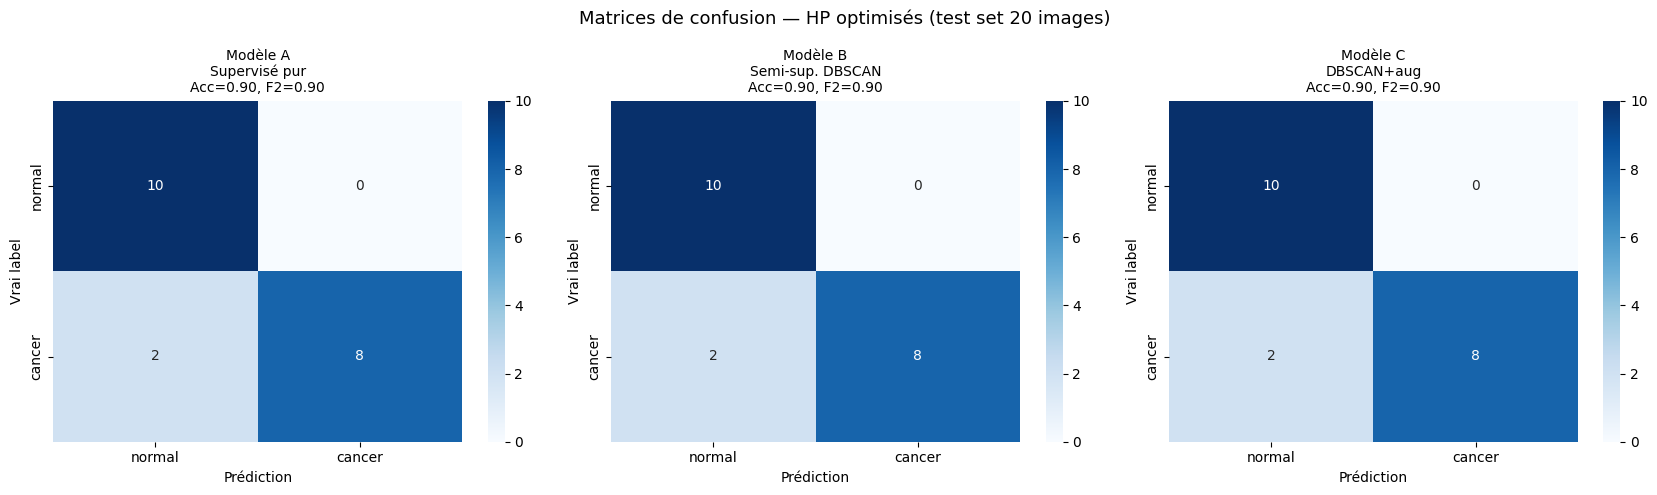

In [18]:
# Matrices de confusion
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Matrices de confusion — HP optimisés (test set 20 images)", fontsize=13)
for ax, y_pred, acc, f2, title in zip(
    axes,
    [y_pred_A, y_pred_B, y_pred_C],
    [acc_A, acc_B, acc_C], [f2_A, f2_B, f2_C],
    ["Modèle A\nSupervisé pur", "Modèle B\nSemi-sup. DBSCAN", "Modèle C\nDBSCAN+aug"]
):
    cm = confusion_matrix(labels_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["normal","cancer"], yticklabels=["normal","cancer"], ax=ax)
    ax.set_title(f"{title}\nAcc={acc:.2f}, F2={f2:.2f}", fontsize=10)
    ax.set_xlabel("Prédiction"); ax.set_ylabel("Vrai label")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrices_hp.png", dpi=150, bbox_inches="tight")
plt.show()

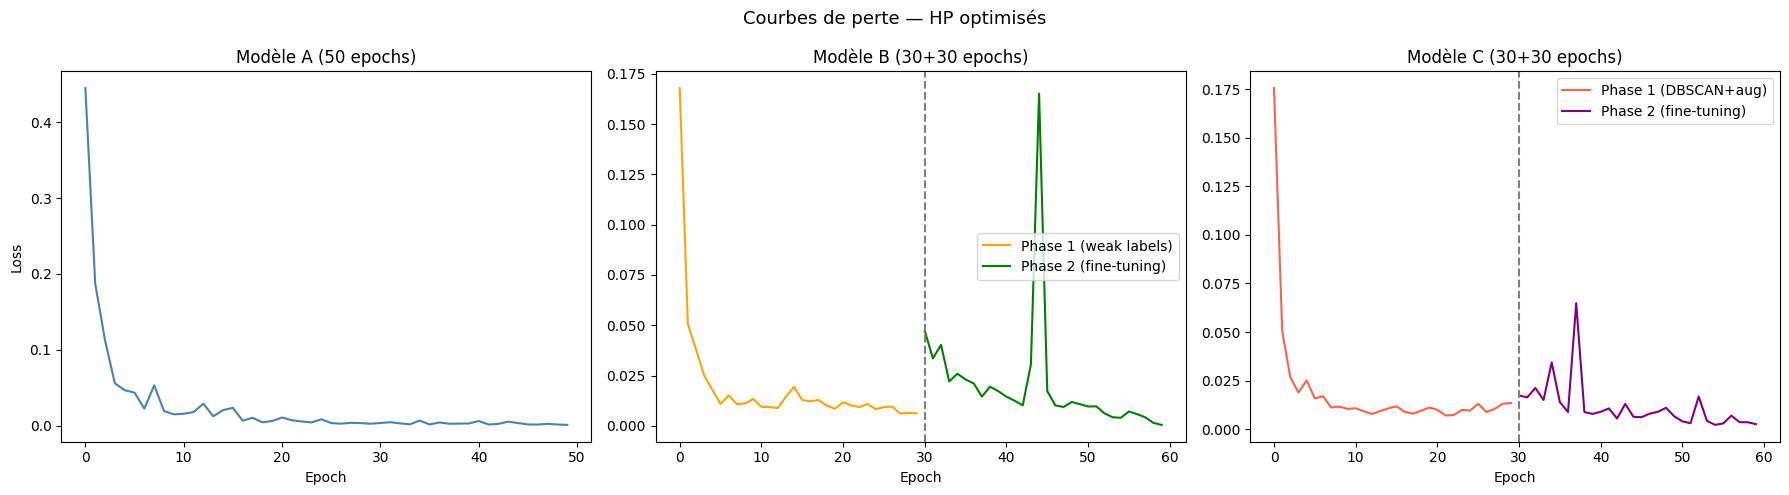

In [19]:
# Courbes d'apprentissage
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Courbes de perte — HP optimisés", fontsize=13)

axes[0].plot(losses_A, color="steelblue")
axes[0].set_title(f"Modèle A ({BEST_EPOCHS} epochs)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")

axes[1].plot(range(EPOCHS_WEAK), losses_B_phase1, color="orange", label="Phase 1 (weak labels)")
axes[1].plot(range(EPOCHS_WEAK, EPOCHS_WEAK+EPOCHS_STRONG), losses_B_phase2, color="green", label="Phase 2 (fine-tuning)")
axes[1].axvline(x=EPOCHS_WEAK, color="gray", linestyle="--")
axes[1].set_title(f"Modèle B ({EPOCHS_WEAK}+{EPOCHS_STRONG} epochs)")
axes[1].set_xlabel("Epoch"); axes[1].legend()

axes[2].plot(range(EPOCHS_WEAK), losses_C_phase1, color="tomato", label="Phase 1 (DBSCAN+aug)")
axes[2].plot(range(EPOCHS_WEAK, EPOCHS_WEAK+EPOCHS_STRONG), losses_C_phase2, color="purple", label="Phase 2 (fine-tuning)")
axes[2].axvline(x=EPOCHS_WEAK, color="gray", linestyle="--")
axes[2].set_title(f"Modèle C ({EPOCHS_WEAK}+{EPOCHS_STRONG} epochs)")
axes[2].set_xlabel("Epoch"); axes[2].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "learning_curves_hp.png", dpi=150, bbox_inches="tight")
plt.show()

## 14b. Courbes ROC — comparaison des 3 modèles

La courbe ROC trace le **taux de vrais positifs (sensibilité)** en fonction du **taux de faux positifs (1 − spécificité)** pour tous les seuils de décision possibles. La diagonale représente un classifieur aléatoire (AUC = 0.5).

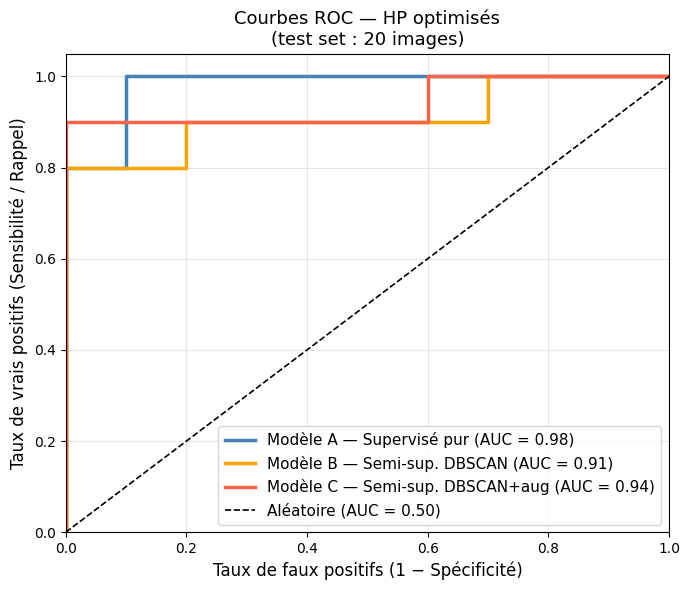

Courbes ROC sauvegardées dans results/roc_curves_hp.png


In [20]:
fig, ax = plt.subplots(figsize=(7, 6))

for y_true, y_proba, label, color in [
    (y_true_A, y_proba_A, f"Modèle A — Supervisé pur (AUC = {auc_A:.2f})",        "steelblue"),
    (y_true_B, y_proba_B, f"Modèle B — Semi-sup. DBSCAN (AUC = {auc_B:.2f})",     "orange"),
    (y_true_C, y_proba_C, f"Modèle C — Semi-sup. DBSCAN+aug (AUC = {auc_C:.2f})", "tomato"),
]:
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    ax.plot(fpr, tpr, color=color, linewidth=2.5, label=label)

ax.plot([0, 1], [0, 1], "k--", linewidth=1.2, label="Aléatoire (AUC = 0.50)")
ax.set_xlabel("Taux de faux positifs (1 − Spécificité)", fontsize=12)
ax.set_ylabel("Taux de vrais positifs (Sensibilité / Rappel)", fontsize=12)
ax.set_title("Courbes ROC — HP optimisés\n(test set : 20 images)", fontsize=13)
ax.legend(loc="lower right", fontsize=11)
ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.05]); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "roc_curves_hp.png", dpi=150, bbox_inches="tight")
plt.show()
print("Courbes ROC sauvegardées dans results/roc_curves_hp.png")

## 15. Sauvegarde des modèles

In [21]:
torch.save(model_A.state_dict(), RESULTS_DIR / "model_A_supervised_hp.pth")
torch.save(model_B.state_dict(), RESULTS_DIR / "model_B_semi_supervised_hp.pth")
torch.save(model_C.state_dict(), RESULTS_DIR / "model_C_semi_supervised_aug_hp.pth")
print("Modèles sauvegardés dans results/ (suffixe _hp.pth)")

Modèles sauvegardés dans results/ (suffixe _hp.pth)


## 16. Conclusions

### Apport de l'optimisation des hyperparamètres

- La recherche par validation croisée (k=5) sur les 80 images train permet de choisir objectivement les HP sans toucher au test set.
- Avec si peu de données, chaque fold de validation ne contient que ~16 images : les scores CV restent bruités. L'optimisation est indicative, pas définitive.
- Un test set plus grand (>100 images) serait nécessaire pour valider rigoureusement l'apport de l'optimisation.

### Comparaison baseline vs HP optimisés

Voir `data/processed/model_comparison_hp_tuning.csv` pour les résultats détaillés.

### Choix des métriques

- **F2-score** (β=2) : métrique optimisée pendant la recherche HP et l'évaluation finale — rappel 2× plus important.
- **ROC-AUC** : mesure la qualité du classement probabiliste, indépendamment du seuil de décision.